# Lab 8 Design Your Own CNN

Name: Anas Kabir

Course: Machine Learning

Performed in: Jupyter Notebook (Anaconda)

Objective:
To design a Convolutional Neural Network (CNN) model for image classification using our own image dataset.

In [2]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
dataset_path = "image_dataset"


data = ImageDataGenerator(
    rescale = 1/255,
    validation_split = 0.2
)


train_data = data.flow_from_directory(
    dataset_path,
    target_size = (64,64),
    batch_size = 4,
    class_mode = "categorical",
    subset = "training"
)


test_data = data.flow_from_directory(
    dataset_path,
    target_size = (64,64),
    batch_size = 4,
    class_mode = "categorical",
    subset = "validation"
)

Found 12 images belonging to 3 classes.
Found 0 images belonging to 3 classes.


In [4]:
model = Sequential()


model.add(Conv2D(
    32,
    (3,3),
    activation="relu",
    input_shape=(64,64,3)
))


model.add(MaxPooling2D(
    pool_size=(2,2)
))


model.add(Conv2D(
    64,
    (3,3),
    activation="relu"
))


model.add(MaxPooling2D(
    pool_size=(2,2)
))


model.add(Flatten())


model.add(Dense(
    64,
    activation="relu"
))


model.add(Dense(
    3,
    activation="softmax"
))


print("CNN model created successfully")

C:\Users\KC\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model created successfully


In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


print("CNN model compiled successfully")

CNN model compiled successfully


In [6]:
history = model.fit(
    train_data,
    epochs = 10
)


print("CNN training completed successfully")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.1667 - loss: 1.5605
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6667 - loss: 1.0023
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6667 - loss: 0.8780
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9167 - loss: 0.6442
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7500 - loss: 0.4585
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.2681
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.1751
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 0.1314
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.0595
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.0506
CNN training completed successfully


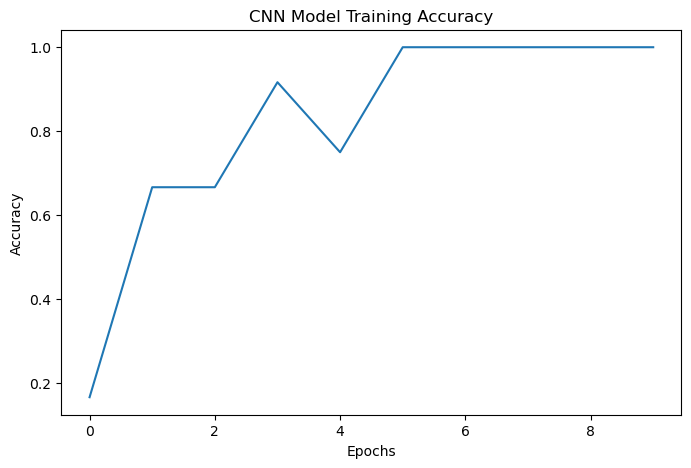

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("CNN Model Training Accuracy")

plt.show()

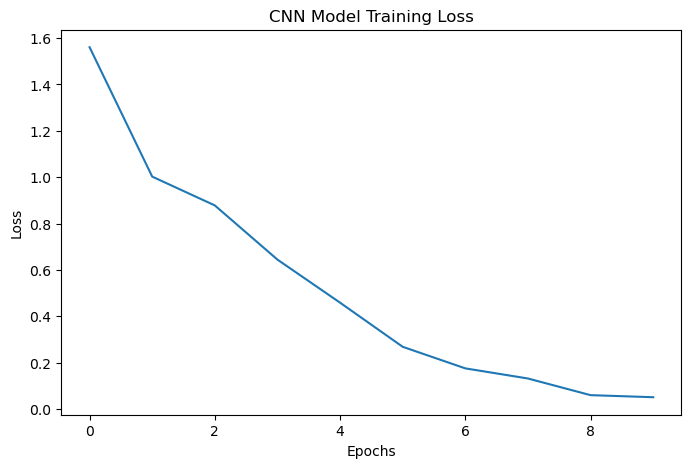

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("CNN Model Training Loss")

plt.show()

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,467,403 (9.41 MB)

 Trainable params: 822,467 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,644,936 (6.27 MB)

In [10]:
model.save("cnn_image_classification_model.h5")

print("CNN model saved successfully")

CNN model saved successfully


## Conclusion

In this lab, a Convolutional Neural Network (CNN) model was designed for image classification.

An image dataset containing cars, cats, and dogs was loaded and preprocessed.

CNN layers including convolution, pooling, flattening, and dense layers were implemented.

The model was trained successfully and accuracy/loss graphs were plotted to analyze performance.

The CNN model successfully learned image features and was saved for future use.